# 03 — Physics-Informed Augmentation Demo

This notebook walks through the synthetic data pipeline step by step:

1. **PDE solver** — visualise source geometries and their solved temperature fields
2. **Blending pipeline** — base image → heat patch → synthetic sample
3. **Gallery** — all 11 anomaly classes: real examples vs synthetic
4. **Diversity** — multiple random seeds for the same class

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from mpl_toolkits.axes_grid1 import make_axes_locatable
import pandas as pd
from PIL import Image

from augmentation.heat_equation import (
    ANOMALY_CLASSES, make_source, solve_heat_2d, blend_heat_patch, synthesise,
)
from training.dataset import load_splits

FIGURES_DIR = Path(".")

splits   = load_splits()
train_df = splits["train"]
print("Loaded training split:", len(train_df), "images")

Loaded training split: 14000 images


---
## 1  PDE solver: source geometry → temperature field

Each anomaly class maps to a distinct heat-source geometry $q(y,x)$.
We solve $\nabla^2 T = -q/\kappa$ with Neumann boundary conditions
to obtain the steady-state temperature rise above ambient.

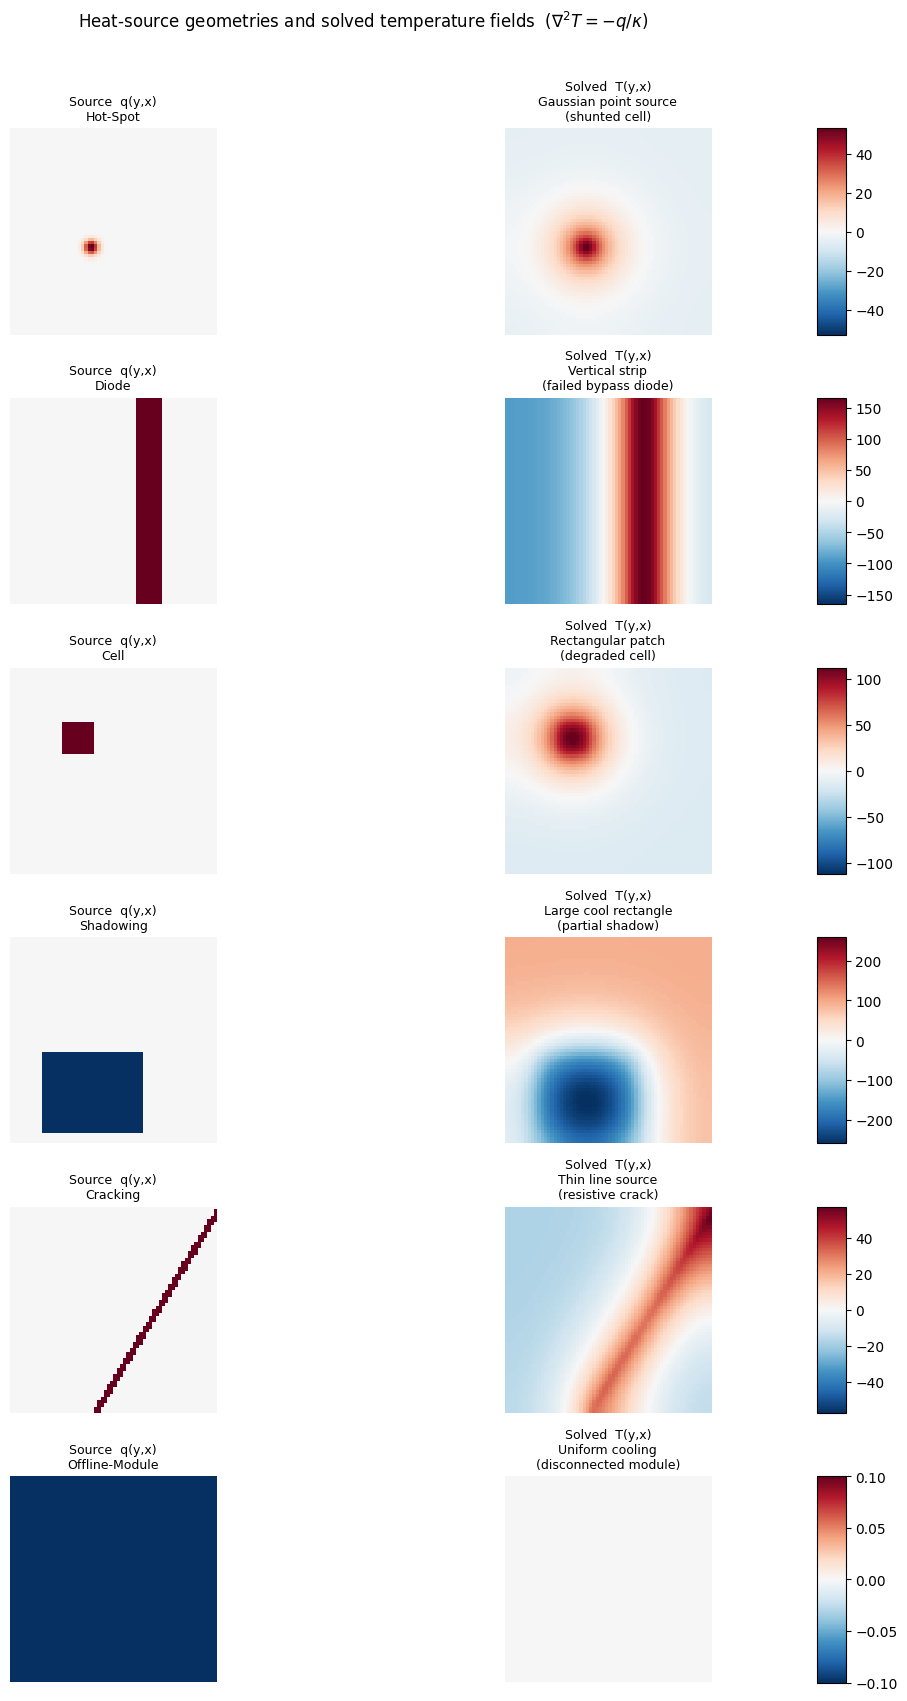

In [2]:
SHOWCASE = [
    ("Hot-Spot",       "Gaussian point source\n(shunted cell)"),
    ("Diode",          "Vertical strip\n(failed bypass diode)"),
    ("Cell",           "Rectangular patch\n(degraded cell)"),
    ("Shadowing",      "Large cool rectangle\n(partial shadow)"),
    ("Cracking",       "Thin line source\n(resistive crack)"),
    ("Offline-Module", "Uniform cooling\n(disconnected module)"),
]

GRID = 64
rng  = np.random.default_rng(7)

fig, axes = plt.subplots(len(SHOWCASE), 3,
                         figsize=(11, 2.8 * len(SHOWCASE)),
                         gridspec_kw={"width_ratios": [1, 1, 0.05]})

for row, (cls, desc) in enumerate(SHOWCASE):
    q = make_source(cls, GRID, GRID, rng=np.random.default_rng(row * 17))
    T = solve_heat_2d(q, max_iter=500)

    peak_q = max(abs(q.max()), abs(q.min()))
    peak_T = max(abs(T.max()), abs(T.min()))

    im0 = axes[row, 0].imshow(q, cmap="RdBu_r", vmin=-peak_q, vmax=peak_q)
    axes[row, 0].set_title(f"Source  q(y,x)\n{cls}", fontsize=9)

    im1 = axes[row, 1].imshow(T, cmap="RdBu_r", vmin=-peak_T, vmax=peak_T)
    axes[row, 1].set_title(f"Solved  T(y,x)\n{desc}", fontsize=9)

    plt.colorbar(im1, cax=axes[row, 2])
    for ax in axes[row, :2]:
        ax.axis("off")

plt.suptitle("Heat-source geometries and solved temperature fields  ($\\nabla^2 T = -q/\\kappa$)",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "pde_fields.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 2  Blending pipeline

The solved temperature field is resized to match the base image, normalised to
$[-1, +1]$, then added (scaled by `intensity_scale`) to all three channels of a
randomly chosen `No-Anomaly` frame.

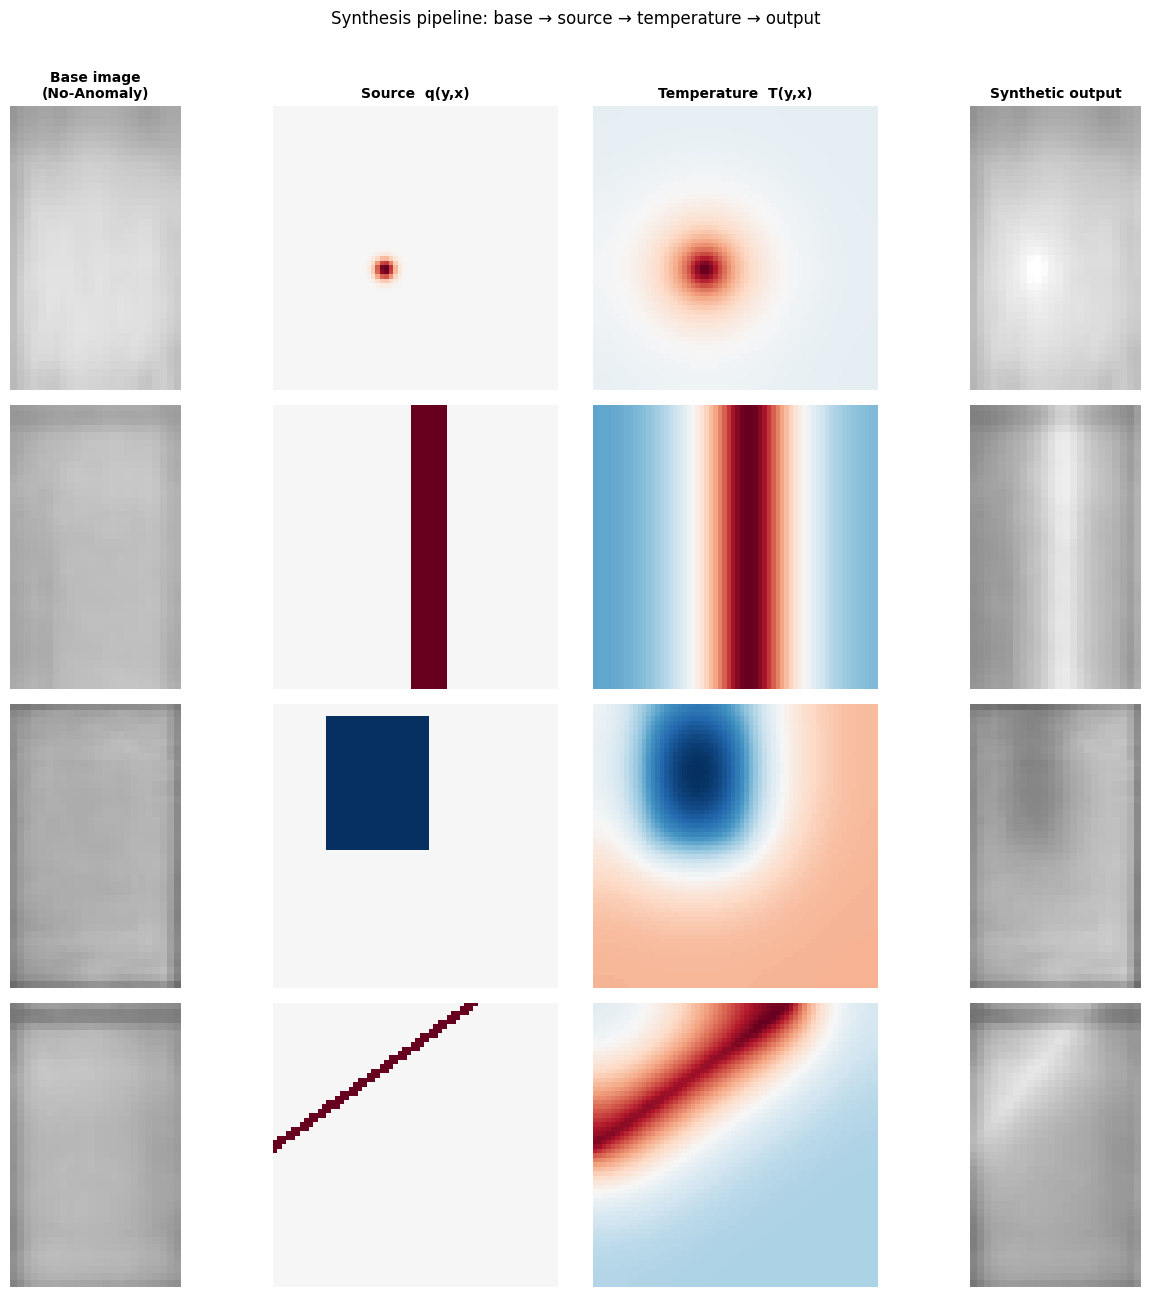

In [3]:
PIPELINE_CLASSES = ["Hot-Spot", "Diode", "Shadowing", "Cracking"]

no_anomaly_paths = train_df.loc[train_df["label"] == "No-Anomaly", "path"].tolist()
rng_pipe = np.random.default_rng(42)

fig, axes = plt.subplots(len(PIPELINE_CLASSES), 4,
                         figsize=(13, 3.2 * len(PIPELINE_CLASSES)))

col_titles = ["Base image\n(No-Anomaly)", "Source  q(y,x)",
              "Temperature  T(y,x)", "Synthetic output"]
for ax, title in zip(axes[0], col_titles):
    ax.set_title(title, fontsize=10, fontweight="bold")

for row, cls in enumerate(PIPELINE_CLASSES):
    base_path = no_anomaly_paths[int(rng_pipe.integers(0, len(no_anomaly_paths)))]
    base_img  = Image.open(base_path).convert("RGB")

    q  = make_source(cls, 64, 64, rng=np.random.default_rng(row))
    T  = solve_heat_2d(q)
    out = blend_heat_patch(base_img, T, intensity_scale=40.0)

    peak = max(abs(T.max()), abs(T.min()))

    axes[row, 0].imshow(base_img, cmap="inferno")
    axes[row, 1].imshow(q,  cmap="RdBu_r",  vmin=-abs(q).max(),  vmax=abs(q).max())
    axes[row, 2].imshow(T,  cmap="RdBu_r",  vmin=-peak, vmax=peak)
    axes[row, 3].imshow(out, cmap="inferno")

    axes[row, 0].set_ylabel(cls, fontsize=10, labelpad=6)
    for ax in axes[row]:
        ax.axis("off")

plt.suptitle("Synthesis pipeline: base → source → temperature → output",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "pipeline.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 3  Gallery — all 11 classes: real vs synthetic

Each row shows one real image from the training set alongside two synthetic
images generated from different `No-Anomaly` bases.

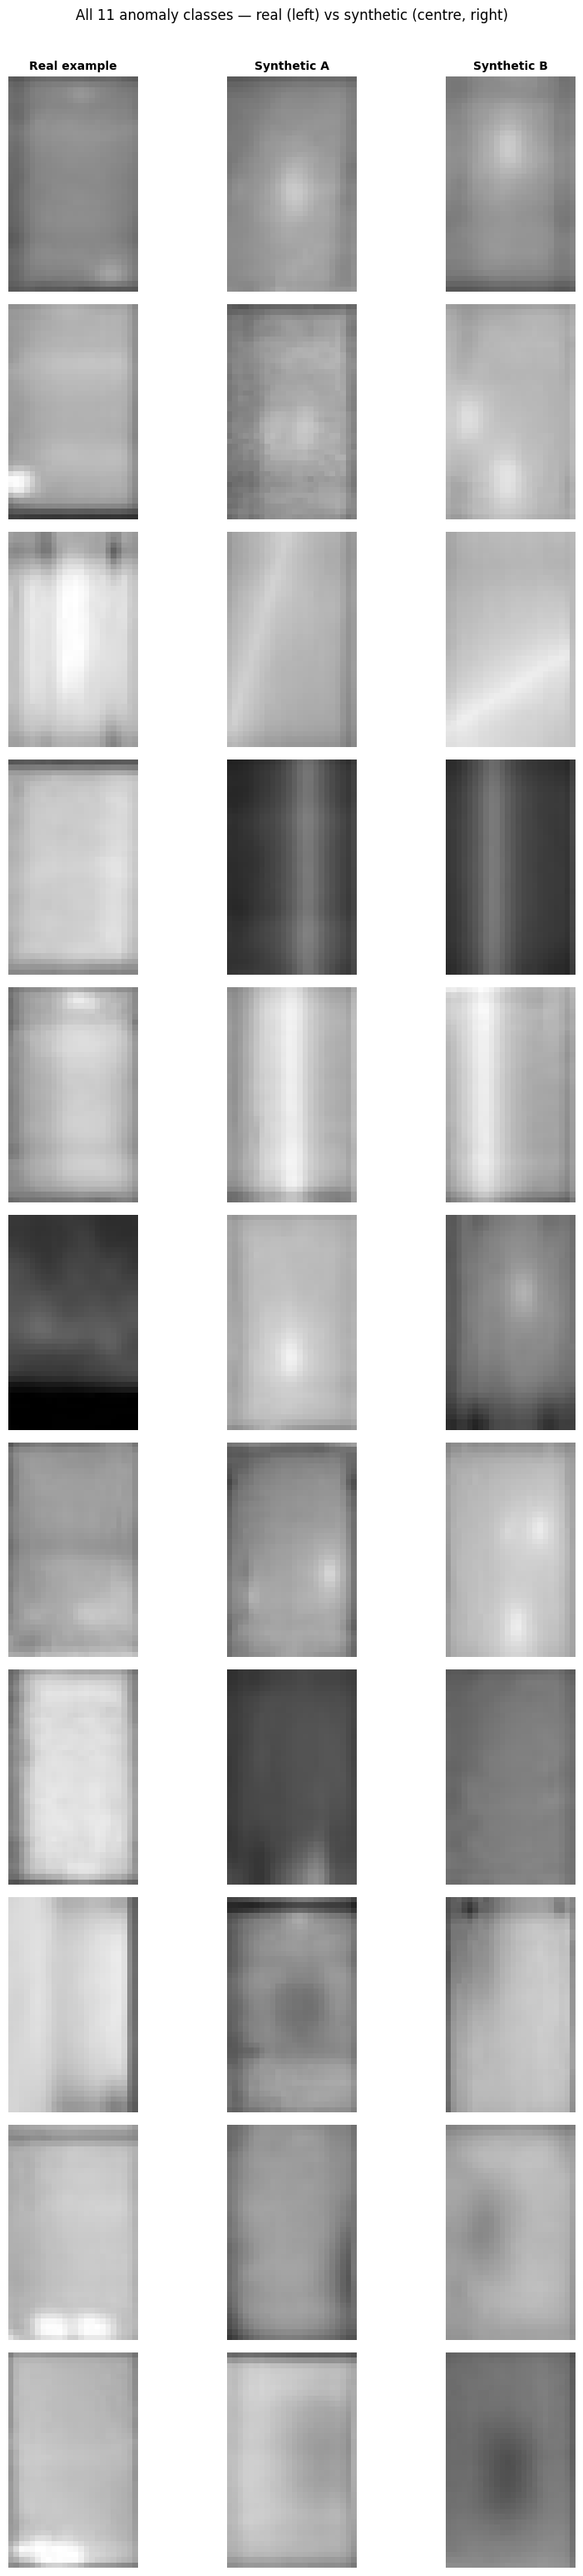

In [4]:
rng_gal = np.random.default_rng(0)

fig, axes = plt.subplots(len(ANOMALY_CLASSES), 3,
                         figsize=(9, 2.8 * len(ANOMALY_CLASSES)))

for ax, title in zip(axes[0], ["Real example", "Synthetic A", "Synthetic B"]):
    ax.set_title(title, fontsize=10, fontweight="bold")

for row, cls in enumerate(ANOMALY_CLASSES):
    # Real image
    real_paths = train_df.loc[train_df["label"] == cls, "path"].tolist()
    real_img   = Image.open(
        real_paths[int(rng_gal.integers(0, len(real_paths)))]
    ).convert("RGB")

    # Two synthetic images from different bases
    for col, seed_offset in enumerate([100, 200], start=1):
        base_path = no_anomaly_paths[
            int(rng_gal.integers(0, len(no_anomaly_paths)))
        ]
        syn = synthesise(
            cls,
            Image.open(base_path).convert("RGB"),
            grid_size=64,
            rng=np.random.default_rng(row * 31 + seed_offset),
        )
        axes[row, col].imshow(syn, cmap="inferno")
        axes[row, col].axis("off")

    axes[row, 0].imshow(real_img, cmap="inferno")
    axes[row, 0].axis("off")
    axes[row, 0].set_ylabel(cls, fontsize=9, labelpad=6)

plt.suptitle("All 11 anomaly classes — real (left) vs synthetic (centre, right)",
             fontsize=12, y=1.005)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "gallery.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 4  Diversity across random seeds

The stochastic source geometry (random location, size, orientation) produces
diverse samples from the same physics model.  Shown here for `Hot-Spot` and `Diode`.

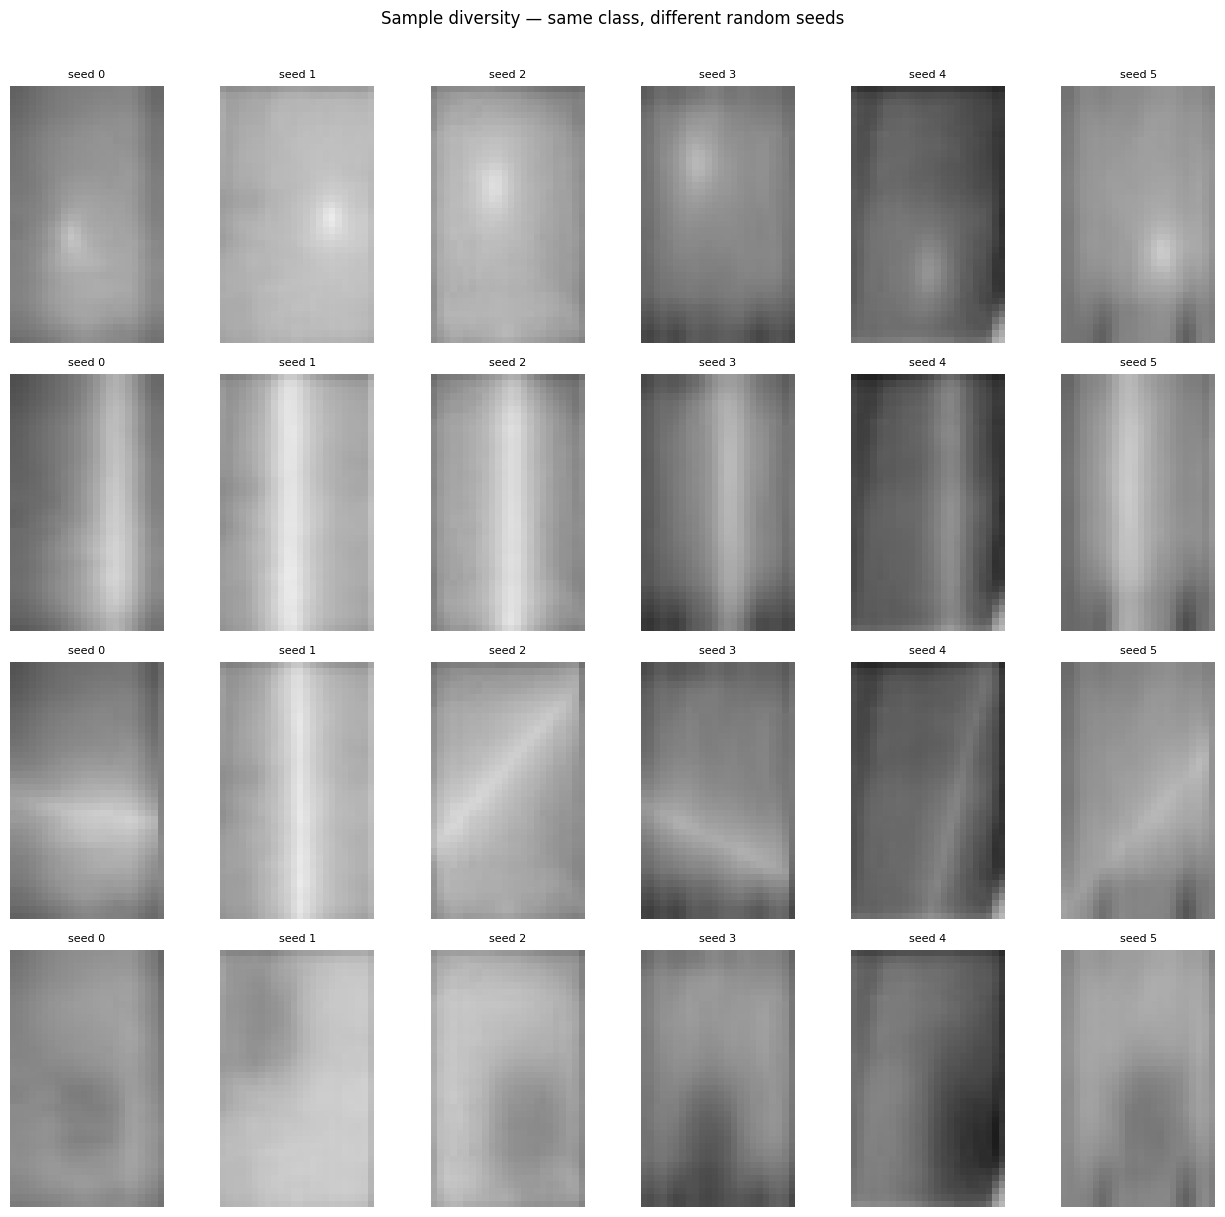

In [5]:
DIVERSITY_CLASSES = ["Hot-Spot", "Diode", "Cracking", "Shadowing"]
N_SEEDS = 6

fig, axes = plt.subplots(len(DIVERSITY_CLASSES), N_SEEDS,
                         figsize=(13, 3 * len(DIVERSITY_CLASSES)))

for row, cls in enumerate(DIVERSITY_CLASSES):
    axes[row, 0].set_ylabel(cls, fontsize=10, labelpad=6)
    for col in range(N_SEEDS):
        base_path = no_anomaly_paths[
            int(np.random.default_rng(col * 7).integers(0, len(no_anomaly_paths)))
        ]
        syn = synthesise(
            cls,
            Image.open(base_path).convert("RGB"),
            grid_size=64,
            rng=np.random.default_rng(row * 100 + col),
        )
        axes[row, col].imshow(syn, cmap="inferno")
        axes[row, col].set_title(f"seed {col}", fontsize=8)
        axes[row, col].axis("off")

plt.suptitle("Sample diversity — same class, different random seeds",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "diversity.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 5  Intensity sensitivity

The `intensity_scale` parameter controls how strongly the temperature delta is
applied.  Too low and the anomaly is invisible; too high and it looks unnatural.

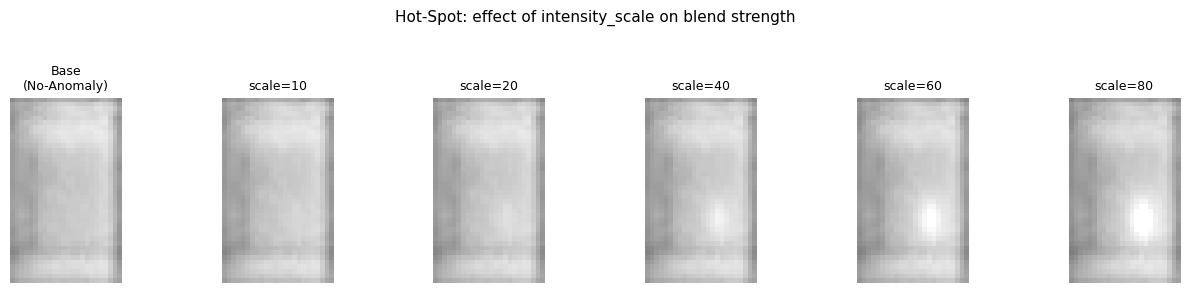

Production value used in training: intensity_scale=40


In [6]:
scales = [10, 20, 40, 60, 80]
rng_int = np.random.default_rng(3)

base_path = no_anomaly_paths[int(rng_int.integers(0, len(no_anomaly_paths)))]
base_img  = Image.open(base_path).convert("RGB")
q  = make_source("Hot-Spot", 64, 64, rng=np.random.default_rng(5))
T  = solve_heat_2d(q)

fig, axes = plt.subplots(1, len(scales) + 1, figsize=(13, 2.8))
axes[0].imshow(base_img, cmap="inferno")
axes[0].set_title("Base\n(No-Anomaly)", fontsize=9)
axes[0].axis("off")

for ax, scale in zip(axes[1:], scales):
    syn = blend_heat_patch(base_img, T, intensity_scale=scale)
    ax.imshow(syn, cmap="inferno")
    ax.set_title(f"scale={scale}", fontsize=9)
    ax.axis("off")

plt.suptitle("Hot-Spot: effect of intensity_scale on blend strength",
             fontsize=11, y=1.03)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "intensity_sweep.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Production value used in training: intensity_scale=40")